ROC AUC Score: 71.82%
Average Precision Score: 40.34%
Brier Score: 21.50%


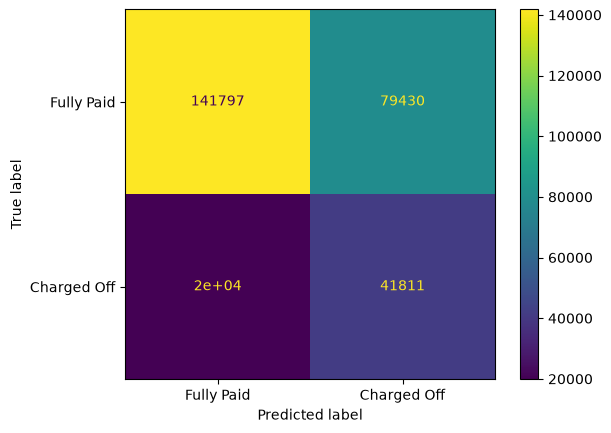

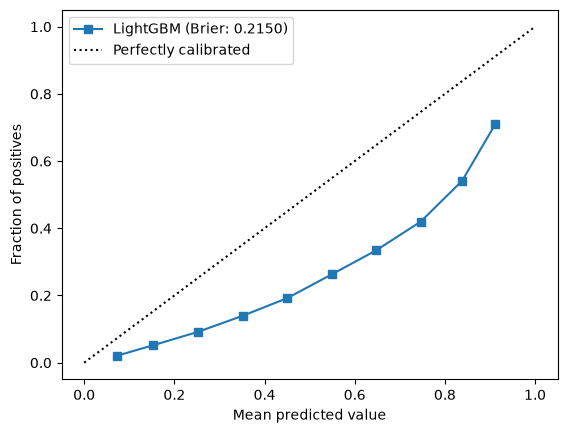

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.preprocessing import get_features

df_train = pd.read_parquet("data/processed/train.parquet")
df_test = pd.read_parquet("data/processed/test.parquet")

X_train = df_train.drop(columns=["target"]).copy()
y_train = df_train["target"].copy()

X_test = df_test.drop(columns=["target"]).copy()
y_test = df_test["target"].copy()

numeric_features, categorical_features = get_features(df_train)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)


lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                is_unbalance=True,
                random_state=42,
                verbose=-1,
                n_jobs=-1,
                learning_rate=0.0562,
                max_depth=9,
                n_estimators=363,
                num_leaves=61,
            ),
        ),
    ],
)

lgbm_pipeline.fit(X_train, y_train)

proba = lgbm_pipeline.predict_proba(X_test)[:, 1]

# Metrics
print(f"ROC AUC Score: {roc_auc_score(y_test, proba):.2%}")
print(f"Average Precision Score: {average_precision_score(y_test, proba):.2%}")


# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, proba >= 0.5, display_labels=["Fully Paid", "Charged Off"]
)


# Brier Score
brier = brier_score_loss(y_test, proba)
print(f"Brier Score: {brier:.2%}")


# Calibration Curve

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, proba, n_bins=10, strategy="uniform"
)

plt.figure()

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    "s-",
    label=f"LightGBM (Brier: {brier:.4f})",
)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.legend()

In [6]:
import numpy as np

# Cost of misclassification (same as week 7)
term_months = df_test["term"].str.extract(r"(\d+)").astype(int).iloc[:, 0]

# Cost of false negatives
fn_cost = np.where(y_test == 1, df_test["funded_amnt"], 0)

# Cost of false positives
fp_cost = np.where(
    y_test == 0, df_test["installment"] * term_months - df_test["funded_amnt"], 0
)

predicted_reject = proba >= 0.5

fn_mask = (y_test == 1) & ~predicted_reject
fp_mask = (y_test == 0) & predicted_reject
total_cost = fn_cost[fn_mask].sum() + fp_cost[fp_mask].sum()


print(f"Cost of rejecting everyone: ${fn_cost.sum():,.2f}")
print(f"Cost of accepting everyone: ${fp_cost.sum():,.2f}")

print(f"Number of false negatives: {fn_mask.sum()}")
print(f"Number of false positives: {fp_mask.sum()}")
print(f"Total cost of misclassification: ${total_cost:,.2f}")
print(
    f"Model savings from rejecting everyone: {(fn_cost.sum() - total_cost) / fn_cost.sum() * 100:.2f}% savings"
)
print(
    f"Model savings from accepting everyone: {(fp_cost.sum() - total_cost) / fp_cost.sum() * 100:.2f}% savings"
)
print(f"Cost of misclassification per loan: ${total_cost / len(y_test):,.2f}")


Cost of rejecting everyone: $976,597,000.00
Cost of accepting everyone: $896,217,549.08
Number of false negatives: 19932
Number of false positives: 79430
Total cost of misclassification: $816,558,705.92
Model savings from rejecting everyone: 16.39% savings
Model savings from accepting everyone: 8.89% savings
Cost of misclassification per loan: $2,885.67
